# Quality Autoencoder V1 — High-Fidelity Reconstruction

This is a separate deterministic Autoencoder experiment designed for visibly better reconstruction. It uses a residual encoder/decoder, bilinear resize-convolution upsampling, a 6× bottleneck, and a combined L1 + SSIM + edge objective. It has no encoder-to-decoder skip connections.

The existing 24× RTX80 Autoencoder and all earlier checkpoints remain unchanged. The quality model is adopted only after validation selection, full 1,892-image test evaluation, and visual inspection.

## 1. Runtime setup
Select **Runtime → Change runtime type → T4 GPU**, then run all cells.

In [1]:
%pip install -q kagglehub Pillow matplotlib numpy pandas scikit-image scikit-learn

In [2]:
import os, sys, json, csv, shutil, subprocess, importlib
from argparse import Namespace
from pathlib import Path, PureWindowsPath
import torch

assert torch.cuda.is_available(), "Enable a GPU runtime: Runtime > Change runtime type > T4 GPU"
GPU_NAME = torch.cuda.get_device_name(0)
print("GPU:", GPU_NAME)

GPU: Tesla T4


## 2. Pull the current project

In [3]:
REPO_URL = "https://github.com/chetanraje27/Digital-Evidence-GenAI.git"
PROJECT_ROOT = Path("/content/Digital-Evidence-GenAI")
if not PROJECT_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "--ff-only"], check=True)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Commit:", subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip())

Commit: 3380ead


## 3. Obtain CASIA v2.0 and validate the canonical manifests

In [4]:
import kagglehub

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
downloaded = None
if not (RAW_DIR / "CASIA2" / "Au").is_dir():
    downloaded = Path(kagglehub.dataset_download(
        "divg07/casia-20-image-tampering-detection-dataset", output_dir=str(RAW_DIR)
    )).resolve()
if not (RAW_DIR / "CASIA2").is_dir():
    roots = [path for path in (downloaded, RAW_DIR) if path is not None and path.exists()]
    candidates = []
    for root in roots:
        if root.name.casefold() == "casia2" and (root / "Au").is_dir() and (root / "Tp").is_dir():
            candidates.append(root)
        candidates.extend(path for path in root.rglob("CASIA2") if (path / "Au").is_dir() and (path / "Tp").is_dir())
    assert candidates, f"CASIA2/Au and CASIA2/Tp were not found under {roots}"
    os.symlink(candidates[0].resolve(), RAW_DIR / "CASIA2", target_is_directory=True)

SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
rows_by_split = {}
for split in ("train", "validation", "test"):
    with (SPLITS_DIR / f"{split}.csv").open(newline="", encoding="utf-8") as file:
        rows_by_split[split] = list(csv.DictReader(file))
assert {name: len(rows) for name, rows in rows_by_split.items()} == {"train": 8830, "validation": 1892, "test": 1892}
paths = [row["image_path"] for rows in rows_by_split.values() for row in rows]
assert len(paths) == len(set(path.casefold() for path in paths)) == 12614
assert all(not Path(path).is_absolute() and not PureWindowsPath(path).is_absolute() for path in paths)
missing = [path for path in paths if not (PROJECT_ROOT / path).is_file()]
assert not missing, f"Missing images, first examples: {missing[:5]}"
print("Canonical split validation: PASS")

100%|██████████| 2.56G/2.56G [01:18<00:00, 34.9MB/s]

Extracting files...


Canonical split validation: PASS


## 4. Architecture and loss smoke checks

In [5]:
import quality_autoencoder, train_quality_autoencoder
importlib.reload(quality_autoencoder)
importlib.reload(train_quality_autoencoder)
from quality_autoencoder import QualityAutoencoder
from train_quality_autoencoder import QualityReconstructionLoss

model = QualityAutoencoder()
sample = torch.rand(2, 3, 128, 128)
with torch.inference_mode():
    latent = model.encode(sample)
    reconstructed = model(sample)
assert latent.shape == (2, 32, 16, 16)
assert reconstructed.shape == sample.shape
assert not any(isinstance(module, torch.nn.ConvTranspose2d) for module in model.modules())
criterion = QualityReconstructionLoss(0.65, 0.25, 0.10)
assert criterion(sample, sample).item() < 1e-5
print("Architecture smoke check: PASS")
print("Parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("Latent:", tuple(latent.shape[1:]), "compression: 6x")

Architecture smoke check: PASS
Parameters: 2371715
Latent: (32, 16, 16) compression: 6x


## 5. Training configuration

Checkpoint selection uses **validation SSIM only**. The held-out test split is not used for training or model selection. Output names are separate from every existing AE checkpoint.

In [6]:
RUN_ROOT = PROJECT_ROOT
TRAIN_ARGS = Namespace(
    splits_dir=SPLITS_DIR,
    checkpoint_path=RUN_ROOT / "checkpoints" / "best_quality_autoencoder_v1.pth",
    history_path=RUN_ROOT / "results" / "quality_ae_v1_training_history.csv",
    summary_path=RUN_ROOT / "results" / "quality_ae_v1_training_summary.json",
    curve_path=RUN_ROOT / "outputs" / "quality_ae_v1" / "training_curve.png",
    grid_path=RUN_ROOT / "outputs" / "quality_ae_v1" / "validation_reconstruction_grid.png",
    image_size=128, batch_size=32, num_workers=2,
    learning_rate=3e-4, min_learning_rate=1e-6, weight_decay=1e-5,
    max_epochs=80, patience=12, lr_patience=4, lr_factor=0.5, min_delta=1e-4,
    l1_weight=0.65, ssim_weight=0.25, edge_weight=0.10,
    seed=42, smoke_test=False, smoke_batches=2, require_cuda=True,
)
print(vars(TRAIN_ARGS))

{'splits_dir': PosixPath('/content/Digital-Evidence-GenAI/data/splits'), 'checkpoint_path': PosixPath('/content/Digital-Evidence-GenAI/checkpoints/best_quality_autoencoder_v1.pth'), 'history_path': PosixPath('/content/Digital-Evidence-GenAI/results/quality_ae_v1_training_history.csv'), 'summary_path': PosixPath('/content/Digital-Evidence-GenAI/results/quality_ae_v1_training_summary.json'), 'curve_path': PosixPath('/content/Digital-Evidence-GenAI/outputs/quality_ae_v1/training_curve.png'), 'grid_path': PosixPath('/content/Digital-Evidence-GenAI/outputs/quality_ae_v1/validation_reconstruction_grid.png'), 'image_size': 128, 'batch_size': 32, 'num_workers': 2, 'learning_rate': 0.0003, 'min_learning_rate': 1e-06, 'weight_decay': 1e-05, 'max_epochs': 80, 'patience': 12, 'lr_patience': 4, 'lr_factor': 0.5, 'min_delta': 0.0001, 'l1_weight': 0.65, 'ssim_weight': 0.25, 'edge_weight': 0.1, 'seed': 42, 'smoke_test': False, 'smoke_batches': 2, 'require_cuda': True}


## 6. Mandatory two-batch smoke run

In [7]:
smoke_dir = Path("/content/quality_ae_smoke")
SMOKE_ARGS = Namespace(**{**vars(TRAIN_ARGS),
    "checkpoint_path": smoke_dir / "model.pth",
    "history_path": smoke_dir / "history.csv",
    "summary_path": smoke_dir / "summary.json",
    "curve_path": smoke_dir / "curve.png",
    "grid_path": smoke_dir / "grid.png",
    "smoke_test": True,
})
smoke_summary = train_quality_autoencoder.train(SMOKE_ARGS)
assert smoke_summary["epochs_completed"] == 1
saved_smoke = torch.load(SMOKE_ARGS.checkpoint_path, map_location="cpu", weights_only=True)
assert saved_smoke["architecture"] == "quality_residual_ae_v1"
print("Training/checkpoint smoke test: PASS")

Epoch 001/001 | train_loss=0.3463607 | val_mse=0.06402120 | val_ssim=0.350901 | lr=3.00e-04 | seconds=22.5
Training/checkpoint smoke test: PASS


## 7. Full GPU training

In [8]:
RUN_FULL_TRAINING = True
if RUN_FULL_TRAINING:
    training_summary = train_quality_autoencoder.train(TRAIN_ARGS)
    print(json.dumps(training_summary, indent=2))
else:
    print("Training skipped.")

Epoch 001/080 | train_loss=0.2311732 | val_mse=0.01828152 | val_ssim=0.573371 | lr=3.00e-04 | seconds=67.4
Epoch 002/080 | train_loss=0.1577965 | val_mse=0.01308328 | val_ssim=0.634494 | lr=3.00e-04 | seconds=52.0
Epoch 003/080 | train_loss=0.1424146 | val_mse=0.01258512 | val_ssim=0.675093 | lr=3.00e-04 | seconds=55.9
Epoch 004/080 | train_loss=0.1316503 | val_mse=0.00742326 | val_ssim=0.701821 | lr=3.00e-04 | seconds=54.1
Epoch 005/080 | train_loss=0.1125319 | val_mse=0.00654829 | val_ssim=0.733762 | lr=3.00e-04 | seconds=54.0
Epoch 006/080 | train_loss=0.1030353 | val_mse=0.00605150 | val_ssim=0.754148 | lr=3.00e-04 | seconds=53.9
Epoch 007/080 | train_loss=0.0957400 | val_mse=0.00522102 | val_ssim=0.773275 | lr=3.00e-04 | seconds=53.9
Epoch 008/080 | train_loss=0.0906358 | val_mse=0.00517618 | val_ssim=0.789285 | lr=3.00e-04 | seconds=54.2
Epoch 009/080 | train_loss=0.0862353 | val_mse=0.00454238 | val_ssim=0.798988 | lr=3.00e-04 | seconds=55.2
Epoch 010/080 | train_loss=0.0826652 

## 8. Inspect validation history and reconstructions

,epoch,train_loss,train_mse,train_ssim,validation_loss,validation_mse,validation_ssim,validation_edge_loss,learning_rate,epoch_time_seconds
75,76,0.030564,0.001009,0.940665,0.030102,0.000969,0.940458,0.022694,0.0003,55.358861
76,77,0.030147,0.000989,0.941619,0.030719,0.001007,0.940031,0.022544,0.0003,54.754775
77,78,0.029972,0.000981,0.942045,0.031211,0.001072,0.940556,0.022594,0.0003,54.260414
78,79,0.030024,0.000988,0.942301,0.029570,0.000958,0.942674,0.022392,0.0003,54.045606
79,80,0.029538,0.000960,0.943138,0.029502,0.000954,0.942450,0.022351,0.0003,54.362634


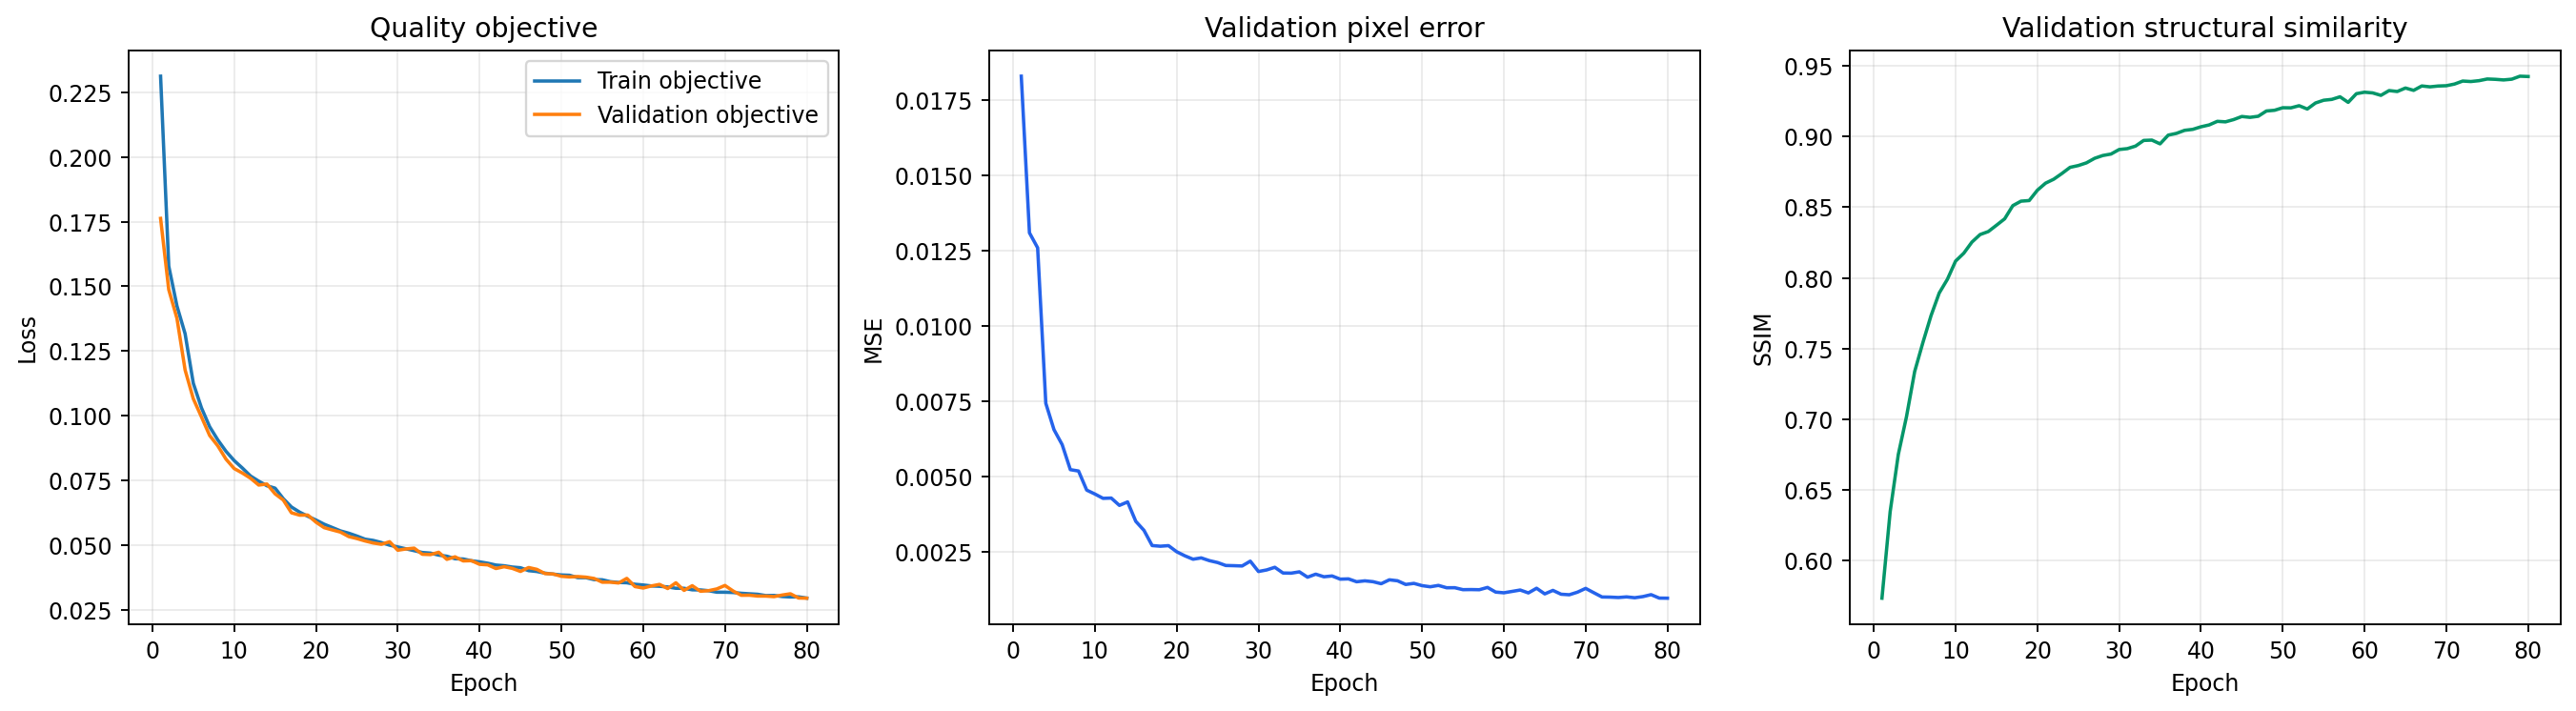

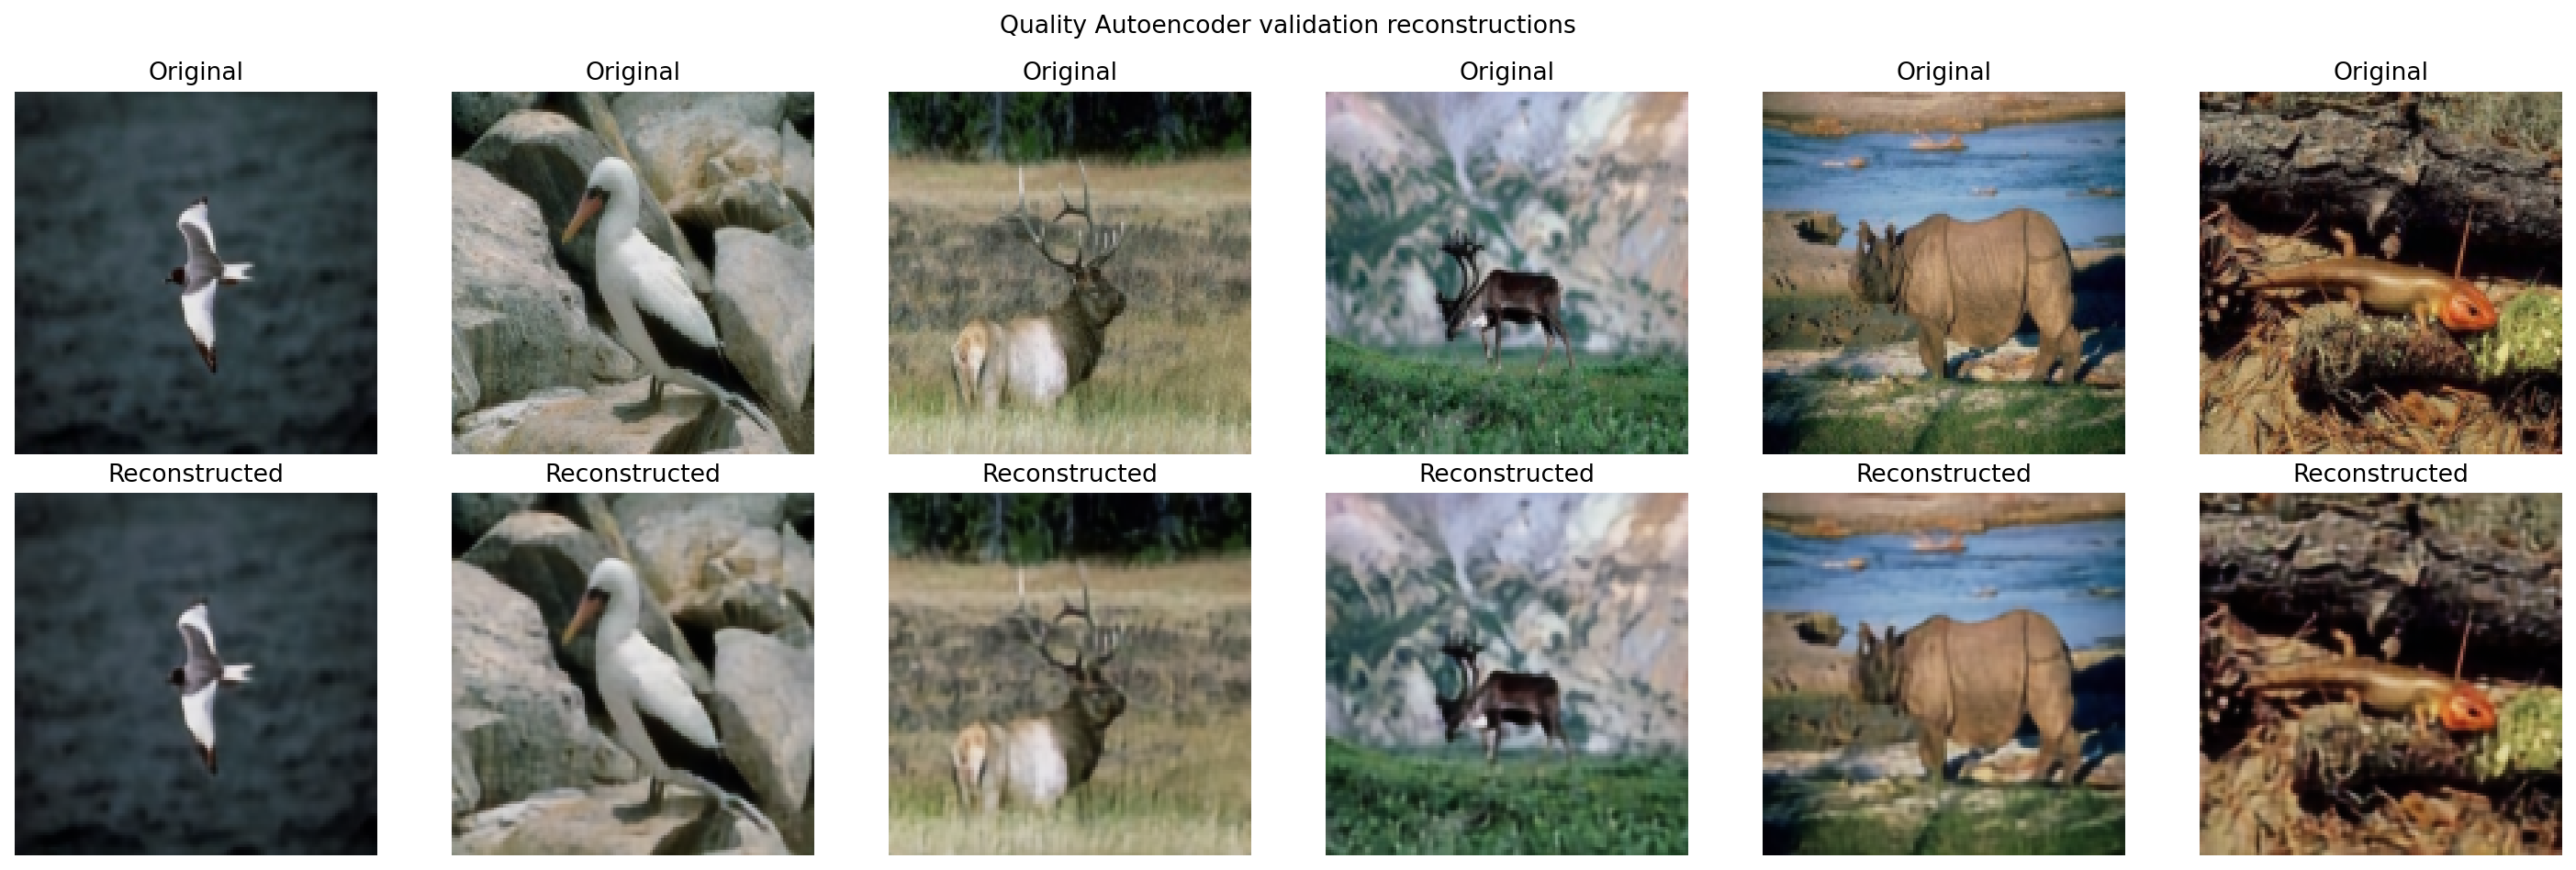

Selected epoch: 79
Validation SSIM: 0.942673691483431
Validation MSE: 0.0009579012228518598


In [9]:
import pandas as pd
from IPython.display import display, Image as DisplayImage

history = pd.read_csv(TRAIN_ARGS.history_path)
display(history.tail())
display(DisplayImage(filename=str(TRAIN_ARGS.curve_path)))
display(DisplayImage(filename=str(TRAIN_ARGS.grid_path)))
best = torch.load(TRAIN_ARGS.checkpoint_path, map_location="cpu", weights_only=True)
print("Selected epoch:", best["epoch"])
print("Validation SSIM:", best["validation_ssim"])
print("Validation MSE:", best["validation_mse"])

## 9. One-time canonical held-out test evaluation

Evaluated 320/1892 images...
Evaluated 640/1892 images...
Evaluated 960/1892 images...
Evaluated 1280/1892 images...
Evaluated 1600/1892 images...
Evaluated 1892/1892 images...
{
  "number_of_test_images": 1892,
  "number_authentic": 1123,
  "number_tampered": 769,
  "architecture": "quality_residual_ae_v1",
  "compression_ratio": 6,
  "checkpoint_epoch": 79,
  "checkpoint_validation_loss": 0.02957003040684202,
  "standard_deviation_definition": "population standard deviation (ddof=0)",
  "overall": {
    "mse_mean": 0.000946025942760688,
    "mse_std": 0.0006841263910980835,
    "psnr_mean": 31.19508006766438,
    "psnr_std": 2.9606091468448605,
    "ssim_mean": 0.9386538375822737,
    "ssim_std": 0.03064770701115437
  },
  "authentic": {
    "mse_mean": 0.0009128778618563962,
    "mse_std": 0.0006635129799451139,
    "psnr_mean": 31.370090391223172,
    "psnr_std": 3.007534718132934,
    "ssim_mean": 0.9412078580363775,
    "ssim_std": 0.030296187269604716
  },
  "tampered": {
    "m

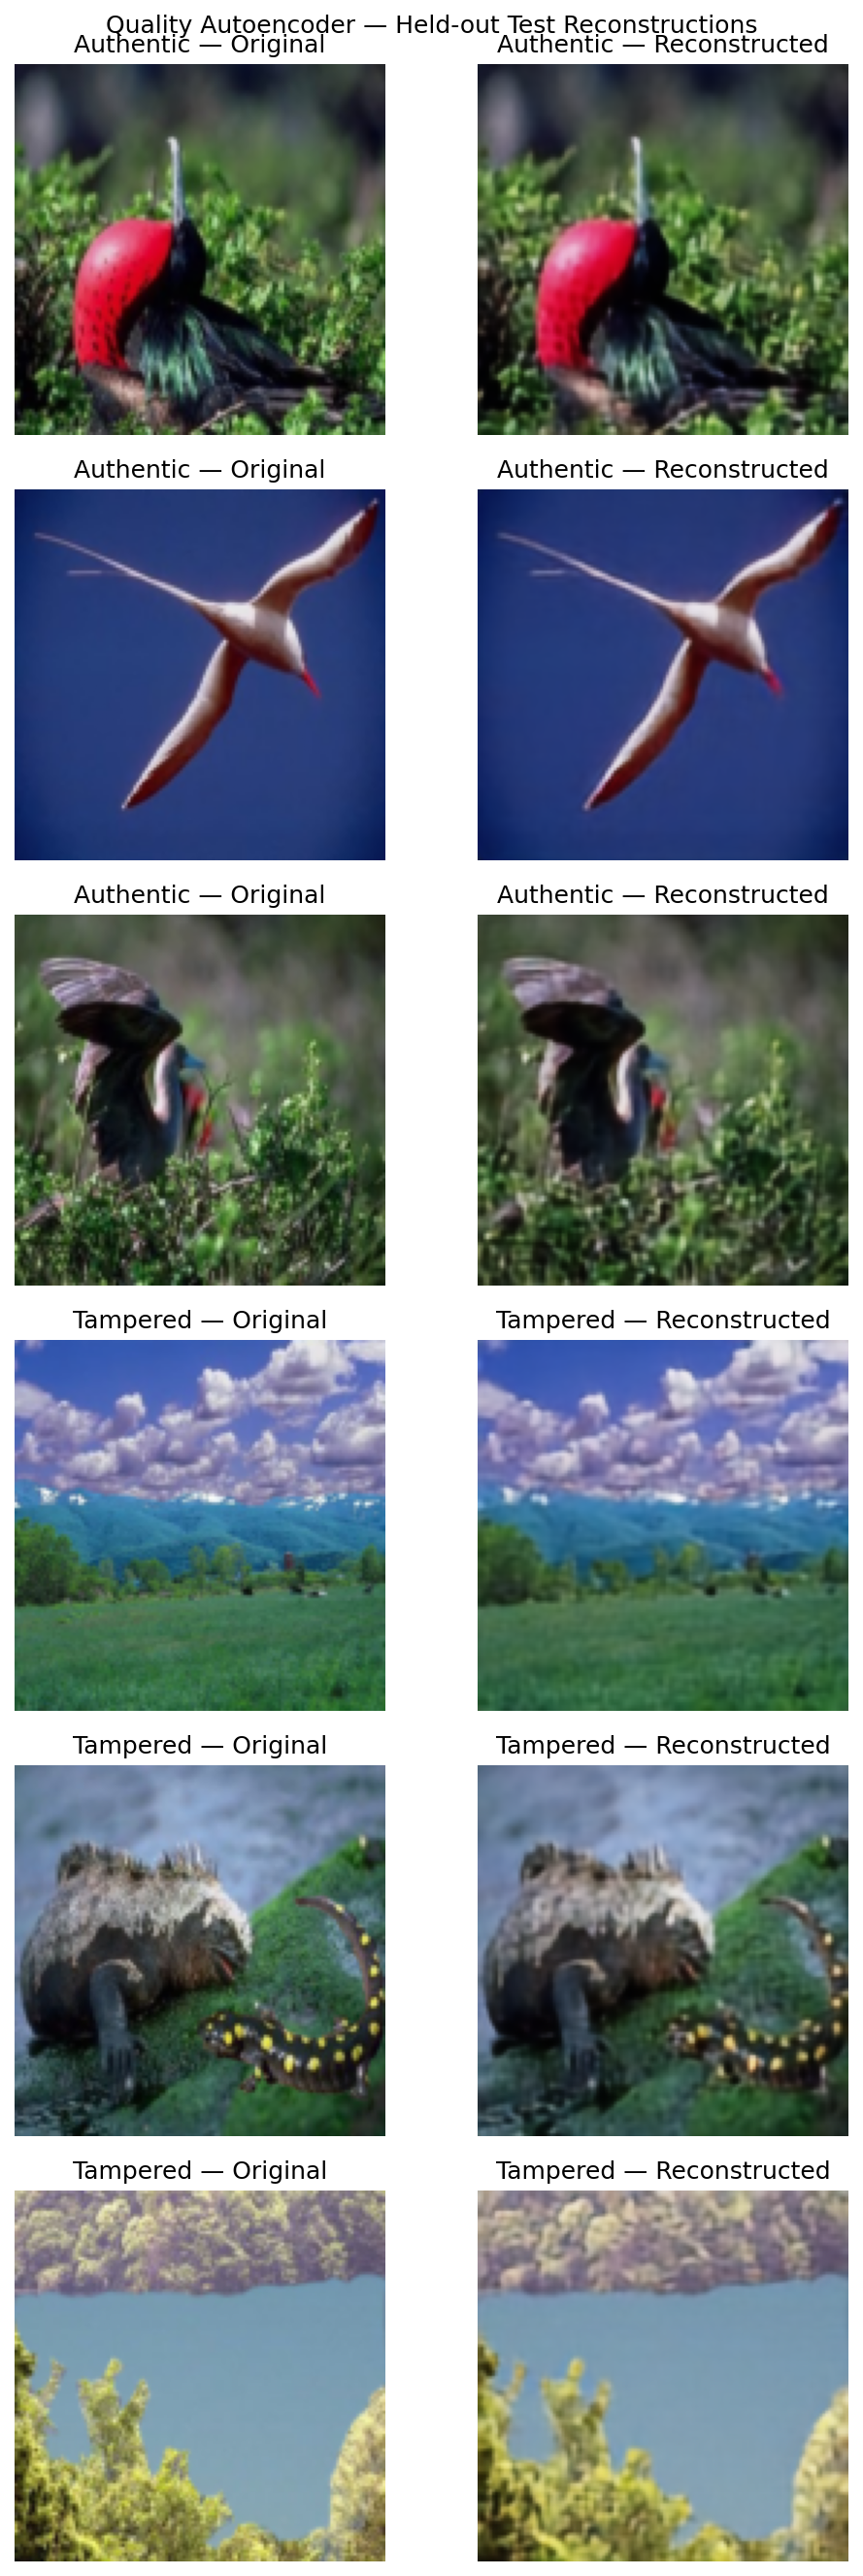

In [10]:
import evaluate_autoencoder
importlib.reload(evaluate_autoencoder)

EVAL_ARGS = Namespace(
    splits_dir=SPLITS_DIR,
    checkpoint_path=TRAIN_ARGS.checkpoint_path,
    per_image_csv=PROJECT_ROOT / "results" / "quality_ae_v1_test_per_image_metrics.csv",
    metrics_json=PROJECT_ROOT / "results" / "quality_ae_v1_test_metrics.json",
    reconstruction_grid=PROJECT_ROOT / "outputs" / "quality_ae_v1" / "test_reconstruction_grid.png",
    mse_plot=PROJECT_ROOT / "outputs" / "quality_ae_v1" / "authentic_vs_tampered_mse.png",
    ssim_plot=PROJECT_ROOT / "outputs" / "quality_ae_v1" / "authentic_vs_tampered_ssim.png",
    image_size=128, batch_size=32, num_workers=2, samples_per_class=3, seed=42,
)
test_metrics = evaluate_autoencoder.evaluate(EVAL_ARGS)
print(json.dumps(test_metrics, indent=2))
display(DisplayImage(filename=str(EVAL_ARGS.reconstruction_grid)))

## 10. Honest comparison with both existing AE results

In [11]:
comparison_rows = []
for label, filename in (
    ("RTX80 baseline (24x)", "ae_rtx80_test_metrics.json"),
    ("RTX80 fine-tuned (24x)", "ae_rtx80_finetuned_test_metrics.json"),
):
    path = PROJECT_ROOT / "results" / filename
    if path.is_file():
        values = json.loads(path.read_text(encoding="utf-8"))
        comparison_rows.append({"model": label, **values["overall"]})
comparison_rows.append({"model": "Quality AE V1 (6x)", **test_metrics["overall"]})
comparison = pd.DataFrame(comparison_rows)
display(comparison[["model", "mse_mean", "psnr_mean", "ssim_mean"]])
baseline = next((row for row in comparison_rows if row["model"].startswith("RTX80 baseline")), None)
if baseline:
    print("Quality AE improves MSE:", test_metrics["overall"]["mse_mean"] < baseline["mse_mean"])
    print("Quality AE improves PSNR:", test_metrics["overall"]["psnr_mean"] > baseline["psnr_mean"])
    print("Quality AE improves SSIM:", test_metrics["overall"]["ssim_mean"] > baseline["ssim_mean"])
print("Visual inspection is still required before adoption.")
print("Reconstruction error is not a tampering probability or forensic verdict.")

,model,mse_mean,psnr_mean,ssim_mean
0,RTX80 baseline (24x),0.003032,26.015853,0.792911
1,Quality AE V1 (6x),0.000946,31.195080,0.938654


Quality AE improves MSE: True
Quality AE improves PSNR: True
Quality AE improves SSIM: True
Visual inspection is still required before adoption.
Reconstruction error is not a tampering probability or forensic verdict.


## 11. Save every required artifact to Google Drive

In [13]:
from google.colab import drive
drive.mount("/content/drive")
DRIVE_PROJECT = Path("/content/drive/MyDrive/Digital_Evidence")
artifact_paths = [
    TRAIN_ARGS.checkpoint_path, TRAIN_ARGS.history_path, TRAIN_ARGS.summary_path,
    TRAIN_ARGS.curve_path, TRAIN_ARGS.grid_path,
    EVAL_ARGS.per_image_csv, EVAL_ARGS.metrics_json, EVAL_ARGS.reconstruction_grid,
    EVAL_ARGS.mse_plot, EVAL_ARGS.ssim_plot,
]
for source in artifact_paths:
    if not source.is_file():
        raise FileNotFoundError(f"Required artifact was not produced: {source}")
    destination = DRIVE_PROJECT / source.relative_to(PROJECT_ROOT)
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    print("Saved:", destination)

Mounted at /content/drive
Saved: /content/drive/MyDrive/Digital_Evidence/checkpoints/best_quality_autoencoder_v1.pth
Saved: /content/drive/MyDrive/Digital_Evidence/results/quality_ae_v1_training_history.csv
Saved: /content/drive/MyDrive/Digital_Evidence/results/quality_ae_v1_training_summary.json
Saved: /content/drive/MyDrive/Digital_Evidence/outputs/quality_ae_v1/training_curve.png
Saved: /content/drive/MyDrive/Digital_Evidence/outputs/quality_ae_v1/validation_reconstruction_grid.png
Saved: /content/drive/MyDrive/Digital_Evidence/results/quality_ae_v1_test_per_image_metrics.csv
Saved: /content/drive/MyDrive/Digital_Evidence/results/quality_ae_v1_test_metrics.json
Saved: /content/drive/MyDrive/Digital_Evidence/outputs/quality_ae_v1/test_reconstruction_grid.png
Saved: /content/drive/MyDrive/Digital_Evidence/outputs/quality_ae_v1/authentic_vs_tampered_mse.png
Saved: /content/drive/MyDrive/Digital_Evidence/outputs/quality_ae_v1/authentic_vs_tampered_ssim.png


## 12. Final measured report

In [14]:
print("GPU:", GPU_NAME)
print("Architecture:", training_summary["architecture"])
print("Compression ratio:", training_summary["compression_ratio"])
print("Best epoch:", training_summary["best_epoch"])
print("Validation MSE:", training_summary["best_validation_mse"])
print("Validation SSIM:", training_summary["best_validation_ssim"])
print("Test MSE:", test_metrics["overall"]["mse_mean"])
print("Test PSNR:", test_metrics["overall"]["psnr_mean"])
print("Test SSIM:", test_metrics["overall"]["ssim_mean"])
print("Checkpoint:", TRAIN_ARGS.checkpoint_path)

GPU: Tesla T4
Architecture: quality_residual_ae_v1
Compression ratio: 6
Best epoch: 79
Validation MSE: 0.0009579012228518598
Validation SSIM: 0.942673691483431
Test MSE: 0.000946025942760688
Test PSNR: 31.19508006766438
Test SSIM: 0.9386538375822737
Checkpoint: /content/Digital-Evidence-GenAI/checkpoints/best_quality_autoencoder_v1.pth
